In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import math as math
import os

In [2]:
# Load the data
# directory='taxi/different_errors/'
directory='taxi/different_errors/'

# Define the custom color palette 
# colors = ['black', 'red', 'green', 'blue'] 
# colors = ['black', '#253494', '#2c7fb8', '#41b6c4', '#a1dab4', 'red'] 
colors = ['black', '#2ca02c', '#0000FF', '#ff7f0e','#d62728', '#00008B']

colors_competitors= ['#0000FF', '#d62728', '#2ca02c']

selected_error_bounds =[0, 0.1, 0.05, 0.02, 0.01]

In [3]:
# Read all CSV files from the different_errors directory
def load_experimental_data(directory):
    all_data = []
    
    # Create a Path object for the directory
    dir_path = Path(directory)
    
    # Iterate through all CSV files in the directory
    for file_path in dir_path.glob('*.csv'):
        flag = False
        if(flag == True): continue;
        df = pd.read_csv(file_path)
        df['run'] = int(file_path.stem.split('_')[-1].replace('run', ''))
        df['errorBound'] = float(file_path.stem.split('_')[1])
        errorBound = (df['errorBound'].unique())[0]
        if(errorBound not in selected_error_bounds): continue;
        all_data.append(df)
    
    # Combine all dataframes
    return pd.concat(all_data, ignore_index=True)


# Read specific e-b CSV files from the directory
def load_specific_experimental_data(directory, eb):
    all_data = []
    
    # Create a Path object for the directory
    dir_path = Path(directory)
    
    # Iterate through all CSV files in the directory
    for file_path in dir_path.glob('*.csv'):
        if(eb not in file_path.stem): continue;
        df = pd.read_csv(file_path)
        df['run'] = int(file_path.stem.split('_')[-1].replace('run', ''))
        all_data.append(df)
    
    # Combine all dataframes
    return pd.concat(all_data, ignore_index=True)

In [4]:

# Function to plot the aggregated results
def plot_aggregated_error_per_column(directory, y_col, include_initialization=False):
    # Load the data
    df = load_experimental_data(directory)

    # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std'),
    ).reset_index()

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]

    color_palette = {error_bound: colors[i % len(colors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create query index for x-axis (assuming 'i' column represents query sequence)
    plt.figure(figsize=(12, 5))
    fontsize=14
    # Plot a line for each error bound without markers
    for error_bound in agg_df['errorBound'].unique():
        data = agg_df[agg_df['errorBound'] == error_bound]
        label = 'Exact' if error_bound == 0 else f'{error_bound * 100:.0f}%'
        plt.plot(data['i'], data['mean_time'], 
                 label=label, 
                 linewidth=2,
                 color=color_palette[error_bound])

    if not include_initialization:
        plt.xlim((1,99))
    plt.xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    plt.ylabel(y_col, fontsize=fontsize, fontweight='bold')
    plt.legend(fontsize = fontsize, frameon=False)  # Remove the box around the legend
    
    # Remove the grid lines behind the plot
    plt.grid(False)

    # Rotate x-axis labels if there are many queries
    plt.xticks(fontsize = fontsize, rotation=0)
    plt.yticks(fontsize = fontsize)

    # Adjust x-axis to start from 1 if initialization is excluded
    if not include_initialization:
        plt.xlim(left=1)

    plt.tight_layout()
    plt.show()

# Function to plot the line chart along with a bar chart showing the summation of time compared to all errors
def plot_aggregated_error_per_column_with_bars(directory, y_col, include_initialization=False):
    # Load the data
    df = load_experimental_data(directory)

    # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]

    color_palette = {error_bound: colors[i % len(colors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create a figure with two subplots side by side with different sizes
    fig = plt.figure(figsize=(15, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    fontsize=14

    # Plot a line for each error bound without markers on the first subplot
    for error_bound in agg_df['errorBound'].unique():
        data = agg_df[agg_df['errorBound'] == error_bound]
        label = 'Exact' if error_bound == 0 else f'{error_bound * 100:.0f}%'
        ax1.plot(data['i'], data['mean_time'], 
                 label=label, 
                 linewidth=2,
                 color=color_palette[error_bound])

    ax1.set_xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    ax1.set_ylabel(y_col, fontsize=fontsize, fontweight='bold')
    ax1.legend(fontsize = fontsize, frameon=False)  # Remove the box around the legend
    
    # Remove the grid lines behind the plot
    ax1.grid(False)

    # Rotate x-axis labels if there are many queries
    ax1.tick_params(axis='x', labelsize=fontsize, rotation=0)
    ax1.tick_params(axis='y', labelsize=fontsize)

    # Adjust x-axis to start from 1 if initialization is excluded
    if not include_initialization:
        ax1.set_xlim((1,99))

    # Create the bar chart on the second subplot
    total_times = agg_df.groupby('errorBound')['mean_time'].sum().reset_index()
    total_times['label'] = total_times['errorBound'].apply(lambda x: 'Exact' if x == 0 else f'{x * 100:.0f}%')
    bars = ax2.bar(total_times['label'], total_times['mean_time'], alpha=0.7)

    # Set the colors of the bars to match the line colors
    for bar, error_bound in zip(bars, total_times['errorBound']):
        bar.set_color(color_palette[error_bound])

    ax2.set_xlabel('Error Bound', fontsize=fontsize, fontweight='bold')
    ax2.set_ylabel(f'Total {y_col}', fontsize=fontsize, fontweight='bold')
    ax2.tick_params(axis='x', labelsize=fontsize, rotation=0)
    ax2.tick_params(axis='y', labelsize=fontsize)

    plt.tight_layout()
    plt.show()

# Function to plot only the bar chart showing the summation of time compared to all errors
def plot_aggregated_error_per_column_bars_only(directory, y_col, include_initialization=False):
    # Load the data
    df = load_experimental_data(directory)

    # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]

    color_palette = {error_bound: colors[i % len(colors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create query index for x-axis (assuming 'i' column represents query sequence)
    plt.figure(figsize=(12, 5))
    fontsize=14
    
    # Create the bar chart
    total_times = agg_df.groupby('errorBound')['mean_time'].sum().reset_index()
    total_times['label'] = total_times['errorBound'].apply(lambda x: 'Exact' if x == 0 else f'{x * 100:.0f}%')
    bars = plt.bar(total_times['label'], total_times['mean_time'], alpha=0.7)

    # Set the colors of the bars to match the line colors
    for bar, error_bound in zip(bars, total_times['errorBound']):
        bar.set_color(color_palette[error_bound])

    plt.xlabel('Error Bound', fontsize=fontsize, fontweight='bold')
    plt.ylabel(f'Total {y_col}', fontsize=fontsize, fontweight='bold')

    # Rotate x-axis labels if there are many queries
    plt.xticks(fontsize = fontsize, rotation=0)
    plt.yticks(fontsize = fontsize)

    plt.tight_layout()
    plt.show()

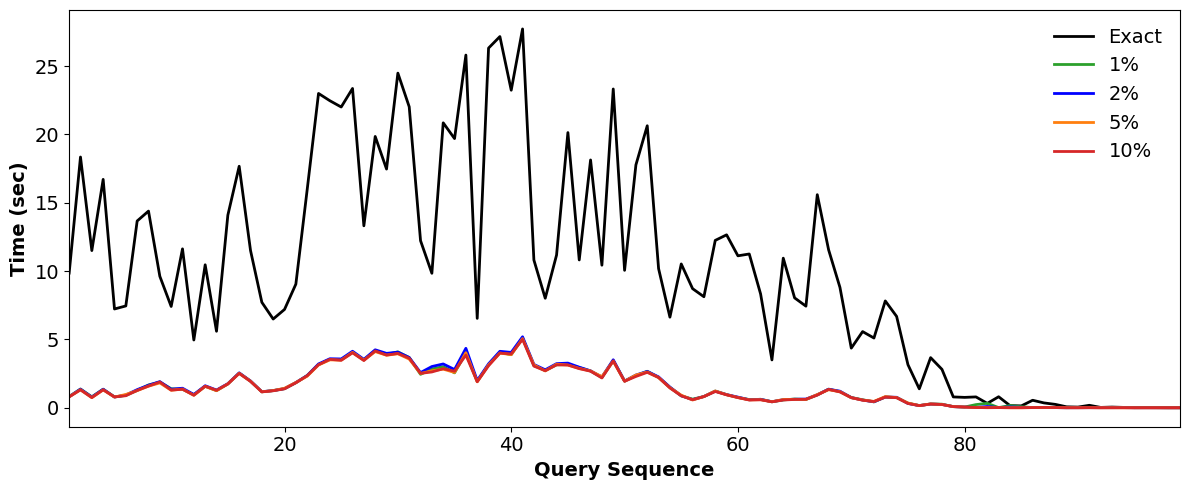

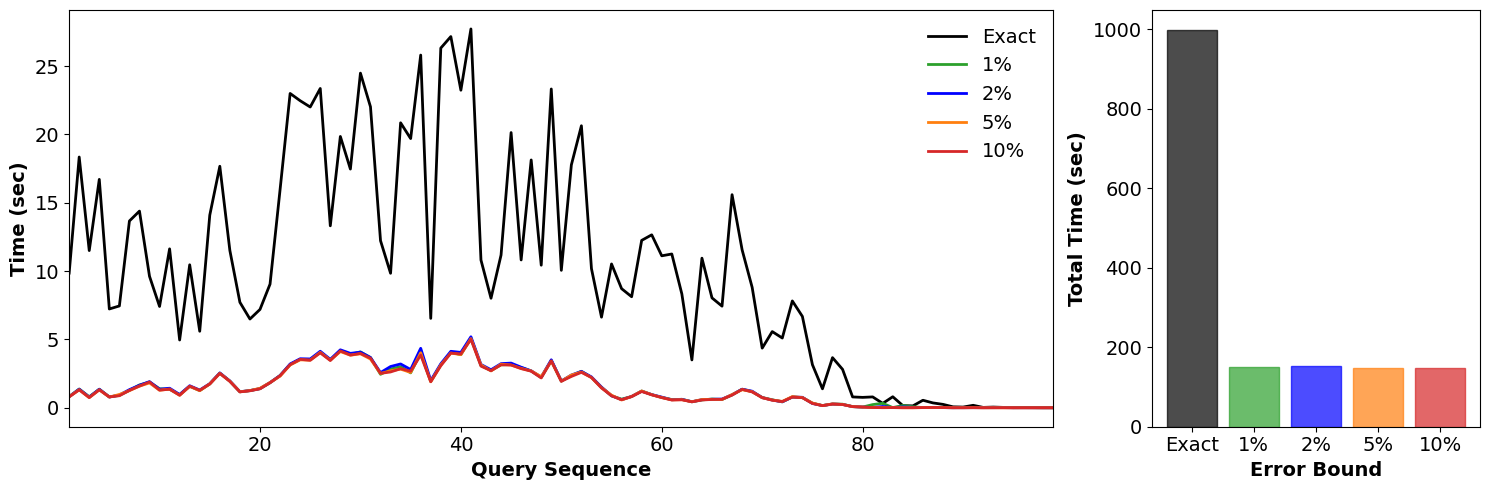

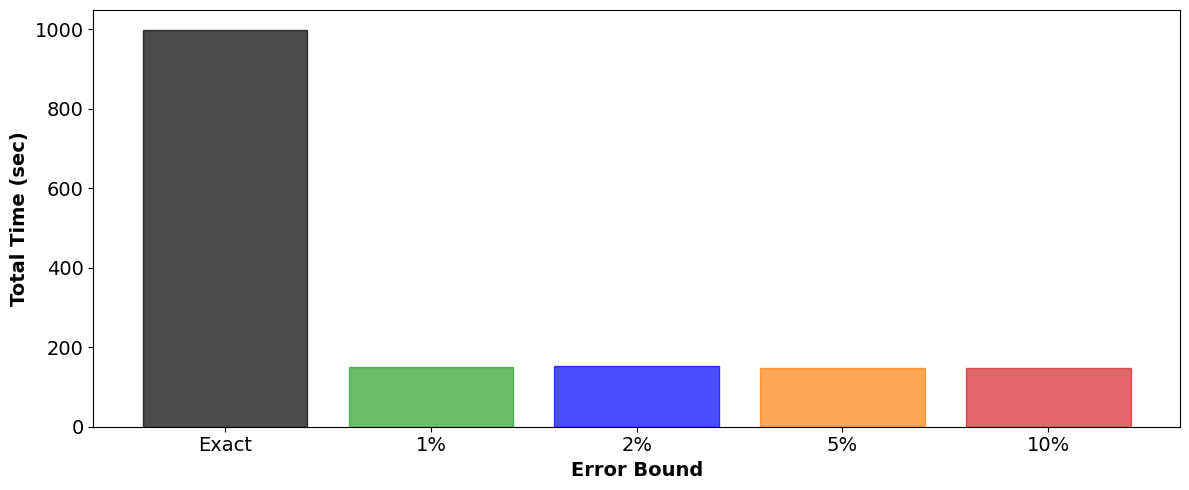

In [5]:
plot_aggregated_error_per_column(directory, 'Time (sec)')
plot_aggregated_error_per_column_with_bars(directory, 'Time (sec)', include_initialization=False)
plot_aggregated_error_per_column_bars_only(directory, 'Time (sec)', include_initialization=False)

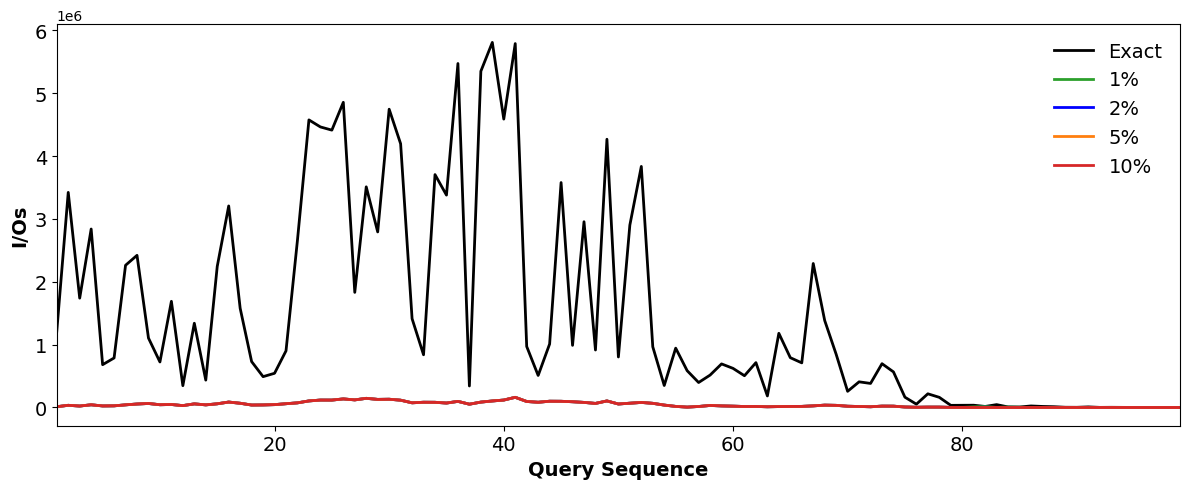

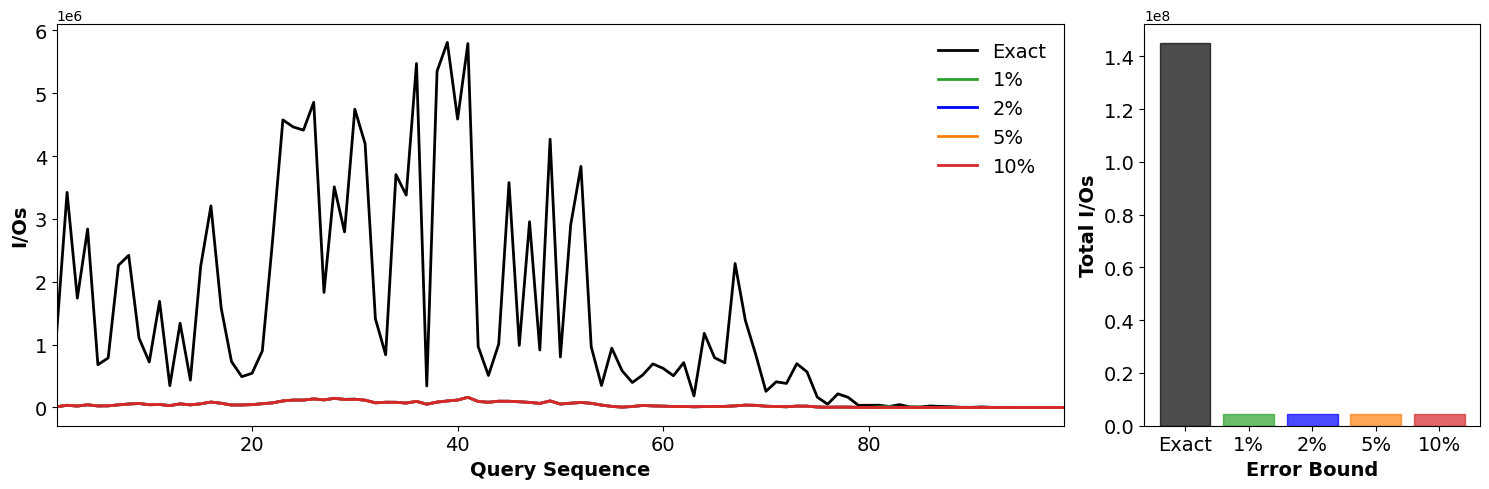

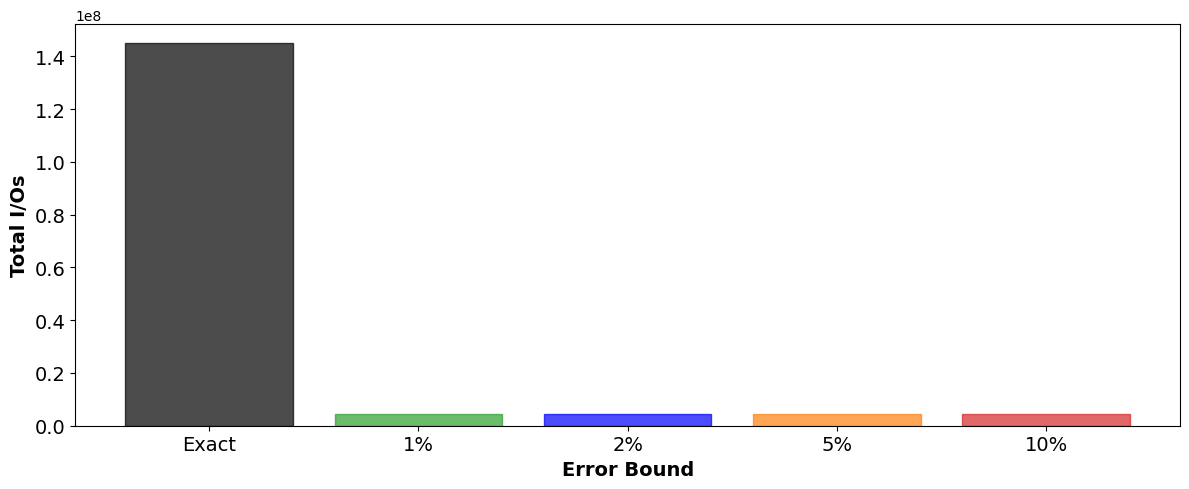

In [8]:
plot_aggregated_error_per_column(directory, 'I/Os')
plot_aggregated_error_per_column_with_bars(directory, 'I/Os', include_initialization=False)
plot_aggregated_error_per_column_bars_only(directory, 'I/Os', include_initialization=False)

In [9]:

def calculate_relative_errors(df_approx, df_exact):
    df_approx.reset_index(inplace=True)
    df_approx['relative_error'] = (abs(df_approx["conf_ub"] - df_approx["conf_lb"]) / 2) / df_exact["ground_truth"]
    return df_approx


# Function to plot the aggregated results
def plot_relative_error_per_error_bound(directory, include_initialization=False):
    # Load the data
    df = load_experimental_data(directory)

    # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        conf_lb=('Confidence Interval LB', 'mean'),
        conf_ub=('Confidence Interval UB', 'mean'),
        ground_truth=("Query Result Sum", 'mean')
    ).reset_index()

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]

    df_exact =  agg_df[agg_df['errorBound'] == 0]
    df_exact.reset_index(inplace=True)
    color_palette = {error_bound: colors[i % len(colors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create query index for x-axis (assuming 'i' column represents query sequence)
    plt.figure(figsize=(12, 5))
    fontsize=14

    # Plot a line for each error bound without markers
    for error_bound in agg_df['errorBound'].unique():
        if(error_bound == 0): continue;
        data = agg_df[agg_df['errorBound'] == error_bound]
        calculate_relative_errors(data, df_exact)
        label = 'Exact' if error_bound == 0 else f'{error_bound * 100:.0f}%'
        plt.plot(data['i'], data['relative_error'], 
                 label=label, 
                 linewidth=2,
                 color=color_palette[error_bound])

    if not include_initialization:
        plt.xlim((1,99))
    plt.xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    plt.ylabel('Relative Error', fontsize=fontsize, fontweight='bold')
    plt.legend(fontsize = fontsize, frameon=False)  # Remove the box around the legend
    
    # Remove the grid lines behind the plot
    plt.grid(False)

    # Rotate x-axis labels if there are many queries
    plt.xticks(fontsize = fontsize, rotation=0)
    plt.yticks(fontsize = fontsize)

    # Adjust x-axis to start from 1 if initialization is excluded
    if not include_initialization:
        plt.xlim(left=1)

    plt.tight_layout()
    plt.show()

/var/folders/cl/rlgfvqcj5bz8p2v_8qkjcb500000gn/T/ipykernel_2450/122686905.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_approx['relative_error'] = (abs(df_approx["conf_ub"] - df_approx["conf_lb"]) / 2) / df_exact["ground_truth"]
/var/folders/cl/rlgfvqcj5bz8p2v_8qkjcb500000gn/T/ipykernel_2450/122686905.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_approx['relative_error'] = (abs(df_approx["conf_ub"] - df_approx["conf_lb"]) / 2) / df_exact["ground_truth"]
/var/folders/cl/rlgfvqcj5bz8p2v_8qkj

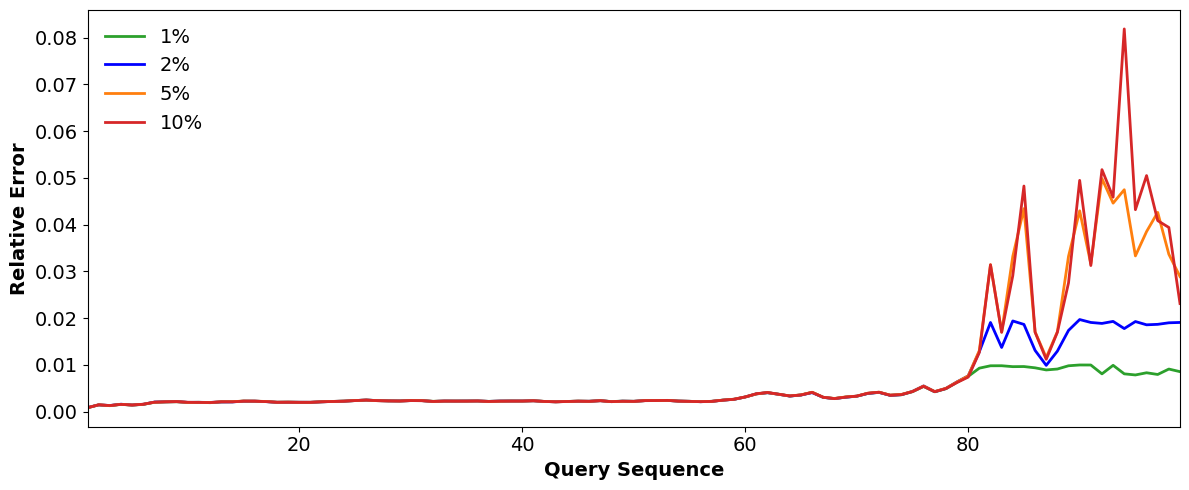

In [10]:
plot_relative_error_per_error_bound(directory, include_initialization=False)

In [17]:
def compare_exact_vs_approx_results(directory, include_initialization=False, approx_error_bound=0.05):
    # Load data using existing function 
    df = load_experimental_data(directory)
    
     # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        conf_lb=('Confidence Interval LB', 'mean'),
        conf_ub=('Confidence Interval UB', 'mean'),
        error_bound=('Error Bound', 'mean'),
        val=('Query Result Sum', 'mean'),
    ).reset_index()
    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]
        
    # Get exact and approximate results
    exact_df = agg_df[agg_df['errorBound'] == 0.0]
    approx_df = agg_df[agg_df['errorBound'] == approx_error_bound]
    
    # Initialize results storage
    results = []
    
    # For each query in the approximate results
    for i in range(len(approx_df)):
        approx_row = approx_df.iloc[i]
        
        # Find matching query in exact results
        exact_row = exact_df[exact_df['i'] == approx_row['i']]
        
        if len(exact_row) == 0:
            continue
            
        exact_sum = exact_row.iloc[0]['val']
        
        # Get confidence interval and error bound
        ci_lb = approx_row['conf_lb']
        ci_ub = approx_row['conf_ub']
        error_bound = approx_row['error_bound']
        
        # Check if exact sum falls within confidence interval
        within_ci = ci_lb <= exact_sum <= ci_ub
        if(not within_ci):
            print(f"Query {i} - Exact: {exact_sum}, CI: ({ci_lb}, {ci_ub})")
        # Calculate actual relative error 
        if exact_sum != 0:
            actual_error = abs(((ci_lb + ci_ub)/2 - exact_sum) / exact_sum)
        else:
            actual_error = float('inf')
            
        results.append({
            'query_index': i,
            'exact_sum': exact_sum,
            'estimated_sum': (ci_lb + ci_ub)/2,
            'ci_lb': ci_lb,
            'ci_ub': ci_ub, 
            'error_bound': error_bound,
            'actual_error': actual_error,
            'within_ci': within_ci
        })
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)

    # Plot results
    plt.figure(figsize=(12, 5))
    fontsize = 14
    
    # Plot exact values
    plt.plot(results_df['query_index'], results_df['exact_sum'], label='Exact', linewidth=2, color='black')
    
    if not include_initialization:
        plt.xlim((0, len(approx_df) - 1))
    # Plot confidence intervals
    plt.fill_between(results_df['query_index'], 
                     results_df['ci_lb'],
                     results_df['ci_ub'],
                     alpha=0.2,
                     color='red',
                     label='Confidence Interval')
    
    plt.xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    plt.ylabel('Query Result Sum', fontsize=fontsize, fontweight='bold')
    plt.legend(fontsize=fontsize, frameon=False)
    plt.grid(False)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.show()
    
    # Calculate summary statistics
    summary = {
        'total_queries': len(results),
        'queries_within_ci': results_df['within_ci'].sum(),
        'avg_actual_error': results_df['actual_error'].mean(),
        'max_actual_error': results_df['actual_error'].max(),
        'avg_error_bound': results_df['error_bound'].mean()
    }
    
    return results_df, summary


def compare_all_error_bounds(directory, include_initialization=False):
    # Load all data using existing function
    df = load_experimental_data(directory)

     # Group by errorBound and query number, then calculate mean and std
    agg_df = df.groupby(['errorBound', 'i']).agg(
        conf_lb=('Confidence Interval LB', 'mean'),
        conf_ub=('Confidence Interval UB', 'mean'),
        error_bound=('Error Bound', 'mean'),
        val=('Query Result Sum', 'mean'),
    ).reset_index()
    print(agg_df)
    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]
    
    # Get unique error bounds and sort them
    error_bounds = sorted(agg_df['errorBound'].unique())
    
    # Get exact results (error bound 0)
    exact_df = agg_df[agg_df['errorBound'] == 0]
    
    plt.figure(figsize=(12, 5))
    fontsize = 14
    
    # Plot exact values
    plt.plot(exact_df['i'], exact_df['val'], 
             label='Exact', linewidth=2, color='black')
    
    if not include_initialization:
        plt.xlim((1, 99))
    
    # Plot each error bound result
    # colors = ['red', 'green', 'blue', 'orange', 'purple']  # Add more colors if needed
    for i, error_bound in enumerate([eb for eb in error_bounds if eb != 0]):
        approx_df = agg_df[agg_df['errorBound'] == error_bound]
        
        # Plot confidence intervals
        plt.fill_between(approx_df['i'], 
                        approx_df['conf_lb'],
                        approx_df['conf_ub'],
                        alpha=0.2,
                        color=colors[(i+1) % len(colors)],
                        label=f'{int(error_bound * 100)} %')
        
        
    
    plt.xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    plt.ylabel('Query Result Sum', fontsize=fontsize, fontweight='bold')
    plt.legend(fontsize=fontsize, frameon=False)
    plt.grid(False)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.show()

    # Print summary statistics for each error bound
    for error_bound in error_bounds:
        bound_df = agg_df[agg_df['errorBound'] == error_bound]
        if error_bound == 0:
            continue
            
        exact_values = exact_df['val'].values
        estimated_values = (bound_df['conf_lb'] + bound_df['conf_ub'])/2
        actual_errors = np.abs(estimated_values - exact_values)/exact_values
        
        within_bounds = ((bound_df['conf_lb'] <= exact_values) & 
                        (bound_df['conf_ub'] >= exact_values)).mean()
        
        print(f"\nError Bound {error_bound}:")
        print(f"Average Actual Error: {actual_errors.mean():.4f}")
        print(f"Max Actual Error: {actual_errors.max():.4f}")
        print(f"Queries within bounds: {within_bounds*100:.1f}%")


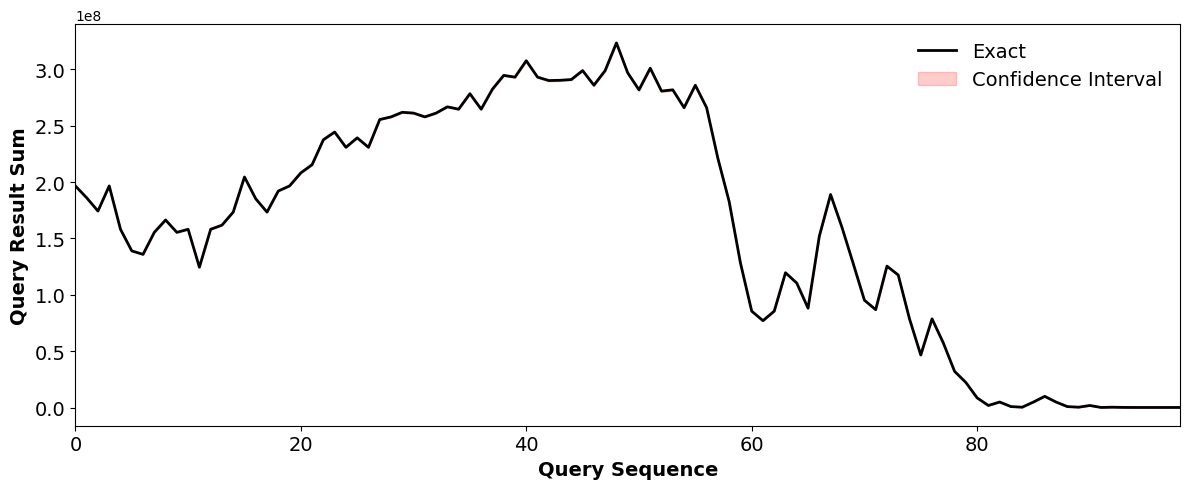

(    query_index     exact_sum  estimated_sum         ci_lb         ci_ub  \
 0             0  1.965599e+08   1.965163e+08  1.963577e+08  1.966750e+08   
 1             1  1.860412e+08   1.860549e+08  1.857857e+08  1.863242e+08   
 2             2  1.742801e+08   1.743552e+08  1.741329e+08  1.745775e+08   
 3             3  1.965599e+08   1.965628e+08  1.962585e+08  1.968670e+08   
 4             4  1.581156e+08   1.581255e+08  1.579063e+08  1.583447e+08   
 ..          ...           ...            ...           ...           ...   
 94           94  1.304695e+05   1.308233e+05  1.264771e+05  1.351695e+05   
 95           95  1.258281e+05   1.276575e+05  1.228114e+05  1.325036e+05   
 96           96  1.304695e+05   1.279311e+05  1.223698e+05  1.334925e+05   
 97           97  1.270579e+05   1.276540e+05  1.233764e+05  1.319316e+05   
 98           98  1.284008e+05   1.278997e+05  1.241911e+05  1.316083e+05   
 
     error_bound  actual_error  within_ci  
 0      0.000807      0.000222

In [18]:
compare_exact_vs_approx_results(directory, approx_error_bound=0.05)

     errorBound   i        conf_lb        conf_ub  error_bound           val
0           0.0   0            NaN            NaN          NaN           NaN
1           0.0   1            NaN            NaN          NaN  1.965599e+08
2           0.0   2            NaN            NaN          NaN  1.860412e+08
3           0.0   3            NaN            NaN          NaN  1.742801e+08
4           0.0   4            NaN            NaN          NaN  1.965599e+08
..          ...  ..            ...            ...          ...           ...
495         0.1  95  122497.172681  133769.773985     0.043934           NaN
496         0.1  96  117542.102164  130250.291169     0.050960           NaN
497         0.1  97  121129.751495  131791.661839     0.042160           NaN
498         0.1  98  123364.617098  133375.652902     0.038540           NaN
499         0.1  99  125259.432876  131194.847124     0.023164           NaN

[500 rows x 6 columns]


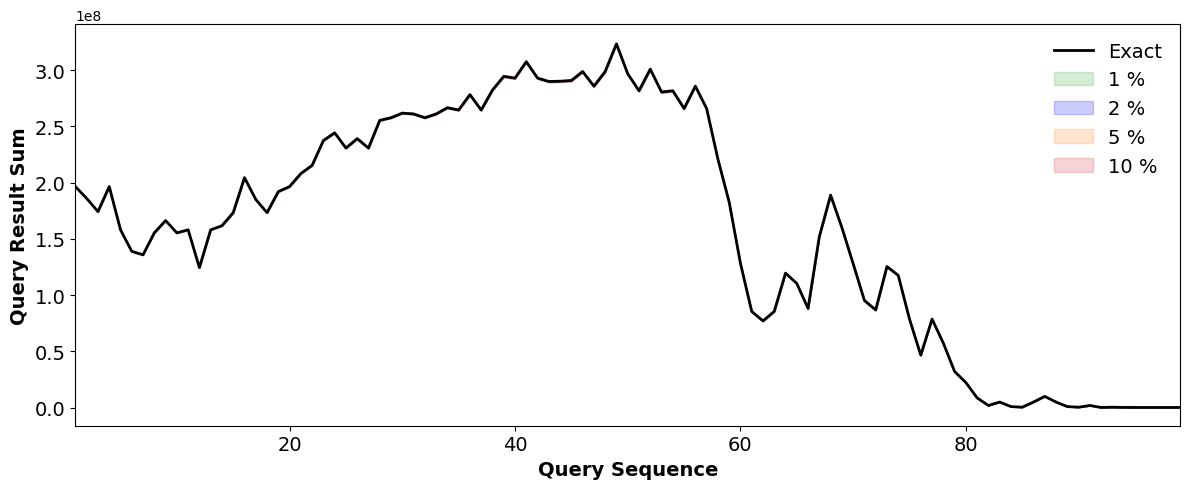


Error Bound 0.01:
Average Actual Error: 0.0008
Max Actual Error: 0.0051
Queries within bounds: 100.0%

Error Bound 0.02:
Average Actual Error: 0.0012
Max Actual Error: 0.0097
Queries within bounds: 100.0%

Error Bound 0.05:
Average Actual Error: 0.0021
Max Actual Error: 0.0195
Queries within bounds: 100.0%

Error Bound 0.1:
Average Actual Error: 0.0022
Max Actual Error: 0.0307
Queries within bounds: 100.0%


In [19]:
compare_all_error_bounds(directory)


# Competitors

In [20]:
valinor_dir = "taxi/different_errors"
valinor_s_dir = "taxi_only_sampling/different_errors"
default_atia_eb = "0.01"

In [21]:
def get_competitor_agg_df(valinor_dir, valinor_s_dir, eb, y_col, include_initialization=False):
    # Load the data
    valinor_s_df = load_specific_experimental_data(valinor_s_dir, eb)

    # Group by errorBound and query number, then calculate mean and std
    valinor_s_agg_df = valinor_s_df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()
    valinor_s_agg_df['errorBound'] = "Valinor-S"

    valinor_df = load_specific_experimental_data(valinor_dir, "_0_")
    
    # Group by errorBound and query number, then calculate mean and std
    valinor_agg_df = valinor_df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()
    valinor_agg_df['errorBound'] = "Valinor"
    atia_df = load_specific_experimental_data(valinor_dir, eb)

    # Group by errorBound and query number, then calculate mean and std
    atia_agg_df = atia_df.groupby(['errorBound', 'i']).agg(
        mean_time=(y_col, 'mean'),
        std_time=(y_col, 'std')
    ).reset_index()
    atia_agg_df['errorBound'] = "ATIA"
    agg_df = pd.concat([valinor_s_agg_df, valinor_agg_df, atia_agg_df], ignore_index=True)

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]
    
    return agg_df



In [22]:

# Function to plot the aggregated results
def plot_aggregated_competitors_per_column(valinor_dir, valinor_s_dir, eb, y_col, include_initialization=False):
    
    agg_df = get_competitor_agg_df(valinor_dir, valinor_s_dir, eb, y_col, include_initialization)

    color_palette = {error_bound: colors_competitors[i % len(colors_competitors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create query index for x-axis (assuming 'i' column represents query sequence)
    plt.figure(figsize=(12, 5))
    fontsize=14
    # Plot a line for each error bound without markers
    for error_bound in agg_df['errorBound'].unique():
        data = agg_df[agg_df['errorBound'] == error_bound]
        label = error_bound
        plt.plot(data['i'], data['mean_time'], 
                 label=label, 
                 linewidth=2,
                 color=color_palette[error_bound])

    if not include_initialization:
        plt.xlim((1,99))
    plt.xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    plt.ylabel(y_col, fontsize=fontsize, fontweight='bold')
    plt.legend(fontsize = fontsize, frameon=False)  # Remove the box around the legend
    
    # Remove the grid lines behind the plot
    plt.grid(False)

    # Rotate x-axis labels if there are many queries
    plt.xticks(fontsize = fontsize, rotation=0)
    plt.yticks(fontsize = fontsize)

    # Adjust x-axis to start from 1 if initialization is excluded
    if not include_initialization:
        plt.xlim(left=1)

    plt.tight_layout()
    plt.show()

# Function to plot the line chart along with a bar chart showing the summation of time compared to all errors
def plot_aggregated_competitors_per_column_with_bars(valinor_dir, valinor_s_dir, eb, y_col, include_initialization=False):
    
    agg_df = get_competitor_agg_df(valinor_dir, valinor_s_dir, eb, y_col, include_initialization)

    color_palette = {error_bound: colors_competitors[i % len(colors_competitors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create a figure with two subplots side by side with different sizes
    fig = plt.figure(figsize=(15, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    fontsize=14

    # Plot a line for each error bound without markers on the first subplot
    for error_bound in agg_df['errorBound'].unique():
        data = agg_df[agg_df['errorBound'] == error_bound]
        ax1.plot(data['i'], data['mean_time'], 
                 label=error_bound, 
                 linewidth=2,
                 color=color_palette[error_bound])

    ax1.set_xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    ax1.set_ylabel(y_col, fontsize=fontsize, fontweight='bold')
    ax1.legend(fontsize = fontsize, frameon=False)  # Remove the box around the legend
    
    # Remove the grid lines behind the plot
    ax1.grid(False)

    # Rotate x-axis labels if there are many queries
    ax1.tick_params(axis='x', labelsize=fontsize, rotation=0)
    ax1.tick_params(axis='y', labelsize=fontsize)

    # Adjust x-axis to start from 1 if initialization is excluded
    if not include_initialization:
        ax1.set_xlim((1,99))

    # Create the bar chart on the second subplot
    total_times = agg_df.groupby('errorBound')['mean_time'].sum().reset_index()
    total_times = total_times.sort_values(by='mean_time')
    total_times['label'] = total_times['errorBound']
    bars = ax2.bar(total_times['label'], total_times['mean_time'], alpha=0.7)

    # Set the colors of the bars to match the line colors
    for bar, error_bound in zip(bars, total_times['errorBound']):
        bar.set_color(color_palette[error_bound])

    ax2.set_xlabel('Error Bound', fontsize=fontsize, fontweight='bold')
    ax2.set_ylabel(f'Total {y_col}', fontsize=fontsize, fontweight='bold')
    ax2.tick_params(axis='x', labelsize=fontsize, rotation=0)
    ax2.tick_params(axis='y', labelsize=fontsize)

    plt.tight_layout()
    plt.show()

# Function to plot only the bar chart showing the summation of time compared to all errors
def plot_aggregated_competitors_per_column_bars_only(valinor_dir, valinor_s_dir, eb, y_col, include_initialization=False):
   
    agg_df = get_competitor_agg_df(valinor_dir, valinor_s_dir, eb, y_col, include_initialization)

    color_palette = {error_bound: colors_competitors[i % len(colors_competitors)] for i, error_bound in enumerate(agg_df['errorBound'].unique())}

    # Create query index for x-axis (assuming 'i' column represents query sequence)
    plt.figure(figsize=(12, 5))
    fontsize=14
    
    # Create the bar chart
    total_times = agg_df.groupby('errorBound')['mean_time'].sum().reset_index()
    total_times = total_times.sort_values(by='mean_time')
    total_times['label'] = total_times['errorBound']
    bars = plt.bar(total_times['label'], total_times['mean_time'], alpha=0.7)

    # Set the colors of the bars to match the line colors
    for bar, error_bound in zip(bars, total_times['errorBound']):
        bar.set_color(color_palette[error_bound])

    plt.xlabel('Error Bound', fontsize=fontsize, fontweight='bold')
    plt.ylabel(f'Total {y_col}', fontsize=fontsize, fontweight='bold')

    # Rotate x-axis labels if there are many queries
    plt.xticks(fontsize = fontsize, rotation=0)
    plt.yticks(fontsize = fontsize)

    plt.tight_layout()
    plt.show()

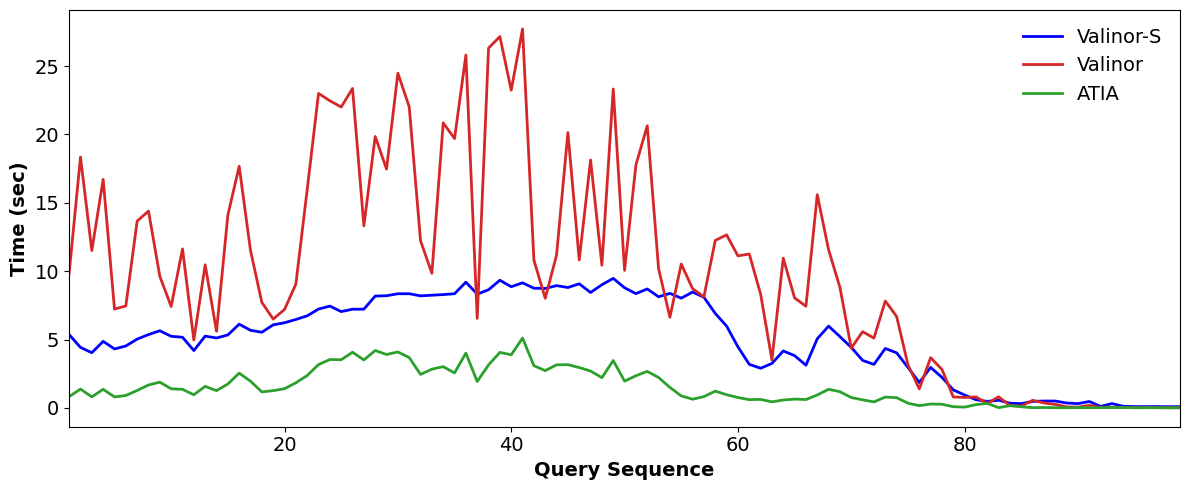

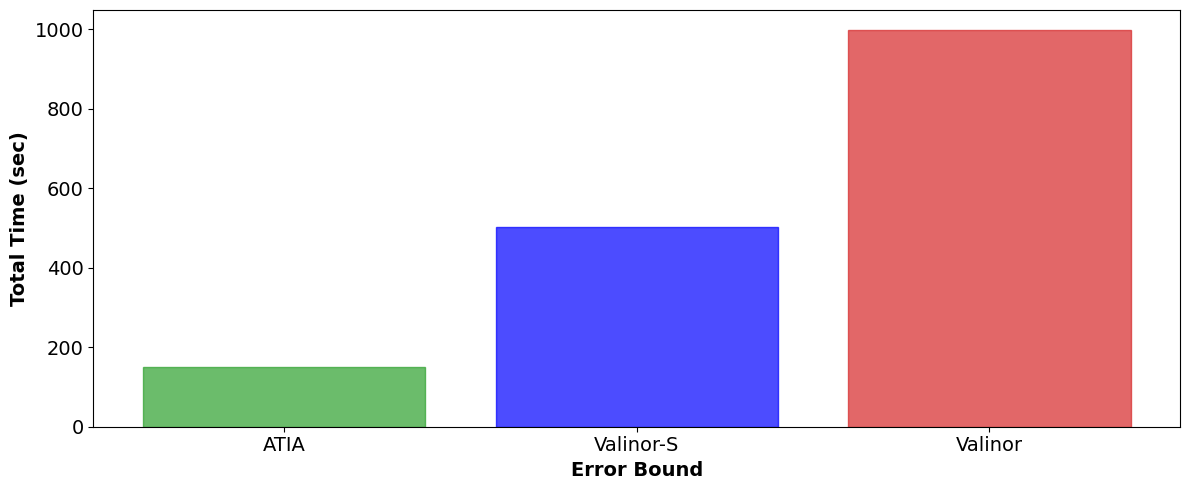

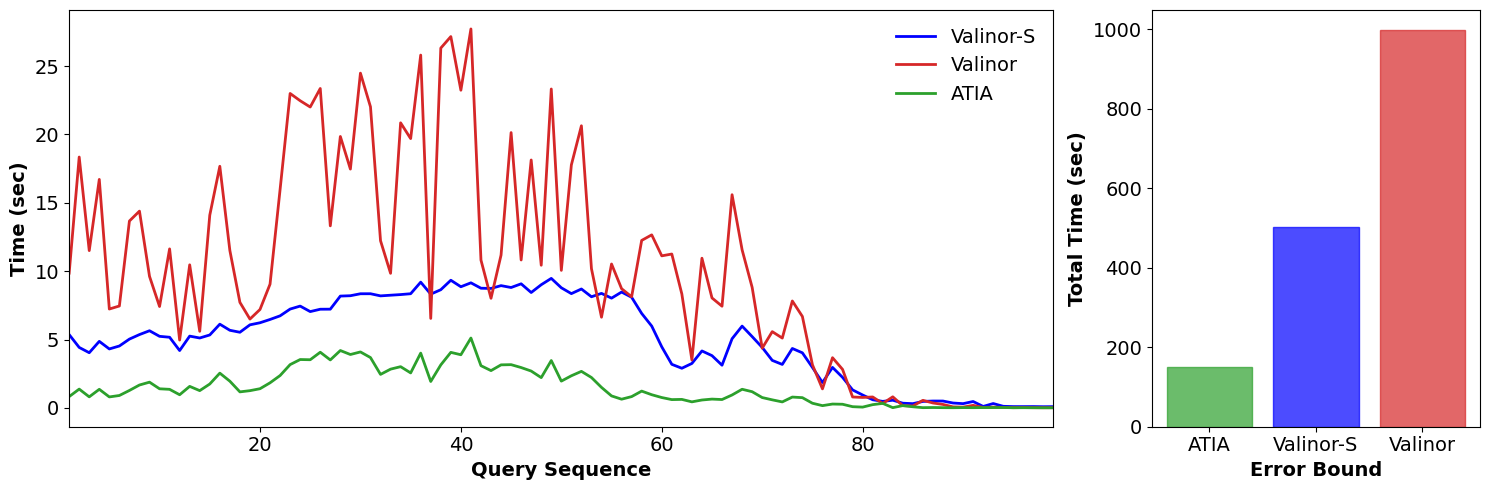

In [23]:
plot_aggregated_competitors_per_column(valinor_dir, valinor_s_dir, default_atia_eb, 'Time (sec)')
plot_aggregated_competitors_per_column_bars_only(valinor_dir, valinor_s_dir, default_atia_eb, 'Time (sec)')
plot_aggregated_competitors_per_column_with_bars(valinor_dir, valinor_s_dir, default_atia_eb, 'Time (sec)')

In [24]:
def get_competitor_agg_df_2(valinor_dir, valinor_s_dir, eb, include_initialization=False):
    # Load the data
    valinor_s_df = load_specific_experimental_data(valinor_s_dir, eb)
    # Group by errorBound and query number, then calculate mean and std
    valinor_s_agg_df = valinor_s_df.groupby('i').agg(
        conf_lb=('Confidence Interval LB', 'mean'),
        conf_ub=('Confidence Interval UB', 'mean'),
        error_bound=('Error Bound', 'mean'),
    ).reset_index()
    valinor_s_agg_df['errorBound'] = "Valinor-S"

    valinor_df = load_specific_experimental_data(valinor_dir, "_0_")
    # Group by errorBound and query number, then calculate mean and std
    valinor_agg_df = valinor_df.groupby('i').agg(
        val=('Query Result Sum', 'mean'),
    ).reset_index()
    valinor_agg_df['errorBound'] = "Valinor"

    atia_df = load_specific_experimental_data(valinor_dir, eb)
    # Group by errorBound and query number, then calculate mean and std
    atia_agg_df = atia_df.groupby('i').agg(
        conf_lb=('Confidence Interval LB', 'mean'),
        conf_ub=('Confidence Interval UB', 'mean'),
        error_bound=('Error Bound', 'mean'),
    ).reset_index()
    atia_agg_df['errorBound'] = "ATIA"
    
    agg_df = pd.concat([valinor_s_agg_df, valinor_agg_df, atia_agg_df], ignore_index=True)

    # Optionally exclude the first point (initialization time)
    if not include_initialization:
        agg_df = agg_df[agg_df['i'] != 0]
    
    return agg_df


In [32]:
def compare_all_competitor_error_bounds(valinor_dir, valinor_s_dir, eb, include_initialization=False):
    # Load all data using existing function
    agg_df = get_competitor_agg_df_2(valinor_dir, valinor_s_dir, eb, include_initialization)

    
    # Get unique error bounds and sort them
    error_bounds = sorted(agg_df['errorBound'].unique())
    
    # Get exact results (error bound 0)
    exact_df = agg_df[agg_df['errorBound'] == "Valinor"]
    
    plt.figure(figsize=(12, 5))
    fontsize = 14
    
    # Plot exact values
    plt.plot(exact_df['i'], exact_df['val'], 
             label='Exact', linewidth=1, color='black')
    
    if not include_initialization:
        plt.xlim((1, 99))
    
    # Plot each error bound result
    # colors = ['red', 'green', 'blue', 'orange', 'purple']  # Add more colors if needed
    for i, error_bound in enumerate([eb for eb in error_bounds if eb != "Valinor"]):
        approx_df = agg_df[agg_df['errorBound'] == error_bound]
        # Plot confidence intervals
        plt.fill_between(approx_df['i'], 
                        approx_df['conf_lb'],
                        approx_df['conf_ub'],
                        alpha=0.2,
                        color=colors_competitors[(i-1) % len(colors_competitors)],
                        label=error_bound)
        
        

    plt.xlabel('Query Sequence', fontsize=fontsize, fontweight='bold')
    plt.ylabel('Query Result Sum', fontsize=fontsize, fontweight='bold')
    plt.legend(fontsize=fontsize, frameon=False)
    plt.grid(False)
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.show()

    # Print summary statistics for each error bound
    for error_bound in error_bounds:
        bound_df = agg_df[agg_df['errorBound'] == error_bound]
        if error_bound == 0:
            continue
            
        exact_values = exact_df['val'].values
        estimated_values = (bound_df['conf_lb'] + bound_df['conf_ub'])/2
        actual_errors = np.abs(estimated_values - exact_values)/exact_values
        
        within_bounds = ((bound_df['conf_lb'] <= exact_values) & 
                        (bound_df['conf_ub'] >= exact_values)).mean()
        
        print(f"\nError Bound {error_bound}:")
        print(f"Average Actual Error: {actual_errors.mean():.4f}")
        print(f"Max Actual Error: {actual_errors.max():.4f}")
        print(f"Queries within bounds: {within_bounds*100:.1f}%")


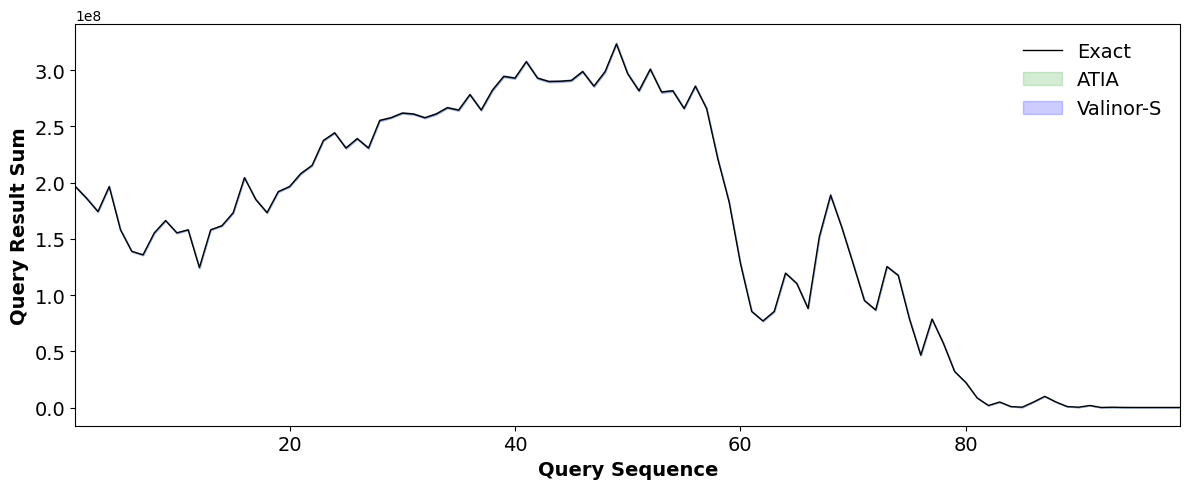


Error Bound ATIA:
Average Actual Error: 0.0008
Max Actual Error: 0.0051
Queries within bounds: 100.0%

Error Bound Valinor:
Average Actual Error: nan
Max Actual Error: nan
Queries within bounds: 0.0%

Error Bound Valinor-S:
Average Actual Error: 0.0008
Max Actual Error: 0.0065
Queries within bounds: 92.9%


In [33]:
compare_all_competitor_error_bounds(valinor_dir, valinor_s_dir, default_atia_eb)